This helper notebook will assist with loading the wine data into pyton

In [26]:
import os
import numpy as np

In [27]:
#paths to the data
data_directory= r"C:\Users\bluek\Downloads\Wine folder"
train_path=os.path.join(data_directory,'wine_training.csv')
test_path=os.path.join(data_directory,'wine_test.csv')

Task 1

In [28]:
#loading the data
d_train = np.loadtxt(train_path, dtype=float, delimiter=',')
d_test = np.loadtxt(test_path, dtype=float, delimiter=',')

X_train = d_train[:, 0:11]
X_test = d_test[:, 0:11]

Y_train = d_train[:,11]
Y_test = d_test[:,11]

print("Training inputs shape: "+str(X_train.shape))
print("Training outputs shape: "+str(Y_train.shape))
print("Test inputs shape: "+str(X_test.shape))
print("Test outputs shape: "+str(Y_test.shape))


Training inputs shape: (1115, 11)
Training outputs shape: (1115,)
Test inputs shape: (479, 11)
Test outputs shape: (479,)


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)

Y_train = scaler_Y.fit_transform(Y_train.reshape(-1, 1)).flatten()

X_test = scaler_X.transform(X_test)
Y_test = scaler_Y.transform(Y_test.reshape(-1, 1)).flatten()

print(f"Training Mean (X): {X_train.mean():.2f}, Std (X): {X_train.std():.2f}")
print(f"Training Mean (Y): {Y_train.mean():.2f}, Std (Y): {Y_train.std():.2f}")

model_1 = LinearRegression()

Coe = model_1.fit(X_train, Y_train)

print("Coefficients (B):")
print(Coe.coef_)

Training Mean (X): 0.00, Std (X): 1.00
Training Mean (Y): -0.00, Std (Y): 1.00
Coefficients (B):
[-0.00334691 -0.30349697 -0.08864764  0.0015453  -0.14462044  0.0833643
 -0.19288915  0.03046118 -0.08408778  0.21289668  0.34923071]


Task 2

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_ols = LinearRegression()
model_ols.fit(X_train, Y_train)

Y_test_pred = model_ols.predict(X_test)

test_mse = mean_squared_error(Y_test, Y_test_pred)
print(f"First Order Model Test MSE: {test_mse:.4f}")

coefficients = model_ols.coef_



First Order Model Test MSE: 0.7472


Task 3

In [31]:
top_5_indices = np.argsort(np.abs(coefficients))[-5:][::-1]
print(f"Indices of the 5 largest predictors: {top_5_indices}")


Indices of the 5 largest predictors: [10  1  9  6  4]


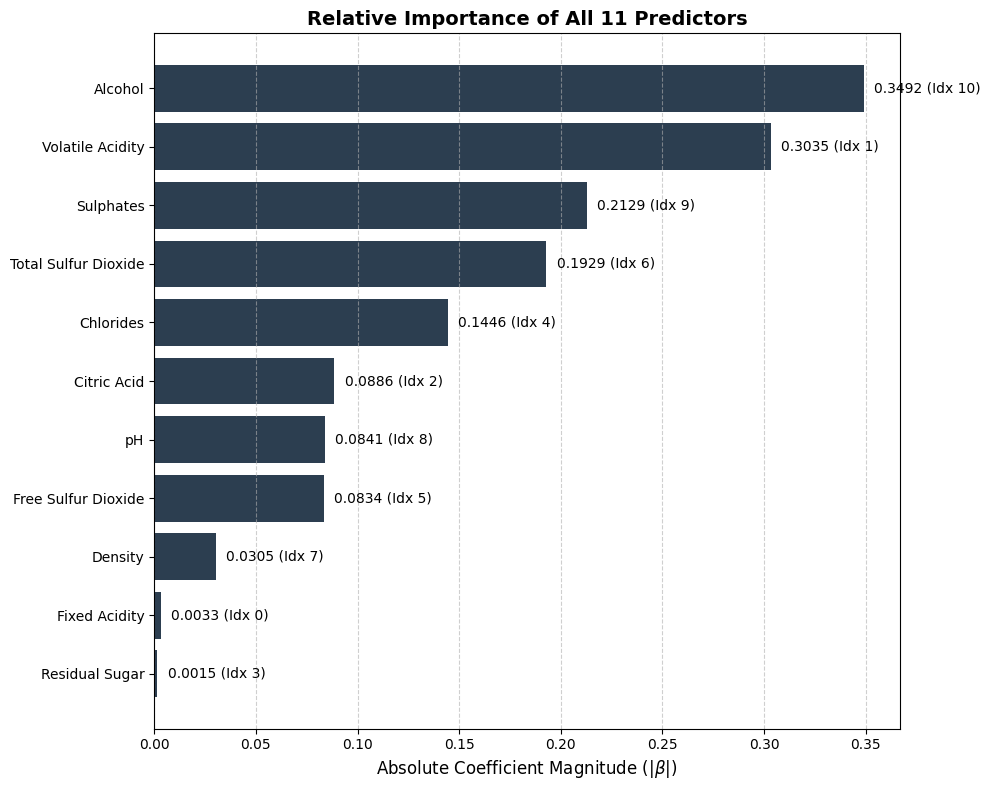

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

feature_names = [
    'Fixed Acidity', 'Volatile Acidity', 'Citric Acid', 'Residual Sugar',
    'Chlorides', 'Free Sulfur Dioxide', 'Total Sulfur Dioxide', 'Density',
    'pH', 'Sulphates', 'Alcohol'
]

df_all = pd.DataFrame({
    'Feature': feature_names,
    'Magnitude': np.abs(coefficients),
    'Index': range(11)
})

df_sorted = df_all.sort_values(by='Magnitude', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_sorted['Feature'], df_sorted['Magnitude'], color='#2c3e50')

plt.xlabel('Absolute Coefficient Magnitude ($|\\beta|$)', fontsize=12)
plt.title('Relative Importance of All 11 Predictors', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, (val, idx) in enumerate(zip(df_sorted['Magnitude'], df_sorted['Index'])):
    plt.text(val + 0.005, i, f'{val:.4f} (Idx {idx})', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('all_predictors_magnitude.png')
plt.show()

Task 4

In [33]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train_quad = np.hstack([X_train, X_train**2])
X_test_quad = np.hstack([X_test, X_test**2])

model_quad = LinearRegression()
model_quad.fit(X_train_quad, Y_train)

Y_test_pred_quad = model_quad.predict(X_test_quad)

test_mse_quad = mean_squared_error(Y_test, Y_test_pred_quad)

print(f"Second Order (No Interactions) Model Test MSE: {test_mse_quad:.4f}")
print(f"Number of features used: {X_train_quad.shape[1]}")

Second Order (No Interactions) Model Test MSE: 0.7806
Number of features used: 22


Task 5

In [34]:
print(f"First Order Model Test MSE: {test_mse:.4f}")
print(f"Second Order (QUAD) Model Test MSE: {test_mse_quad:.4f}")


First Order Model Test MSE: 0.7472
Second Order (QUAD) Model Test MSE: 0.7806


Since the quadratic model has a higher test MSE, it generalizes worse to unseen data. Adding quadratic terms increases the number of parameters, making the model more flexible. While this can reduce bias by allowing nonlinear relationships, it also increases variance.

Task 6

In [35]:
index = [1, 4, 6, 9, 10]

X_train_inter = X_train.copy()
X_test_inter = X_test.copy()

for i in range(len(index)):
    for j in range(i+1, len(index)):
        Xi = index[i]
        Xj = index[j]

        train_interaction = (X_train[:, Xi] * X_train[:, Xj]).reshape(-1, 1)
        test_interaction  = (X_test[:, Xi]  * X_test[:, Xj]).reshape(-1, 1)

        X_train_inter = np.hstack([X_train_inter, train_interaction])
        X_test_inter  = np.hstack([X_test_inter, test_interaction])

In [36]:
model_inter = LinearRegression()
model_inter.fit(X_train_inter, Y_train)

Y_test_pred_inter = model_inter.predict(X_test_inter)

test_mse_inter = mean_squared_error(Y_test, Y_test_pred_inter)

print(f"Interaction Model Test MSE: {test_mse_inter:.4f}")
print(f"Number of features used: {X_train_inter.shape[1]}")

Interaction Model Test MSE: 0.7175
Number of features used: 21


Task 7

In [37]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_inter, Y_train)

best_alpha = lasso_cv.alpha_
print("Selected alpha:", best_alpha)

Selected alpha: 0.0093260334688322


In [38]:
from sklearn.linear_model import Lasso

lasso_final = Lasso(alpha=best_alpha, max_iter=10000)
lasso_final.fit(X_train_inter, Y_train)

Y_test_pred_lasso = lasso_final.predict(X_test_inter)

test_mse_lasso = mean_squared_error(Y_test, Y_test_pred_lasso)

print(f"Lasso Interaction Model Test MSE: {test_mse_lasso:.4f}")

Lasso Interaction Model Test MSE: 0.7045


In [39]:
nonzero_idx = np.where(lasso_final.coef_ != 0)[0]
print("Nonzero coefficient indices:", nonzero_idx)

Nonzero coefficient indices: [ 1  2  4  5  6  8  9 10 12 13 16 17 18 20]


Task 8

In [40]:
print("First Order MSE:", test_mse)
print("Quadratic MSE:", test_mse_quad)
print("Interaction OLS MSE:", test_mse_inter)
print("Lasso Interaction MSE:", test_mse_lasso)

First Order MSE: 0.7471696905187208
Quadratic MSE: 0.7805821192127657
Interaction OLS MSE: 0.7175224728219506
Lasso Interaction MSE: 0.7044753009303107


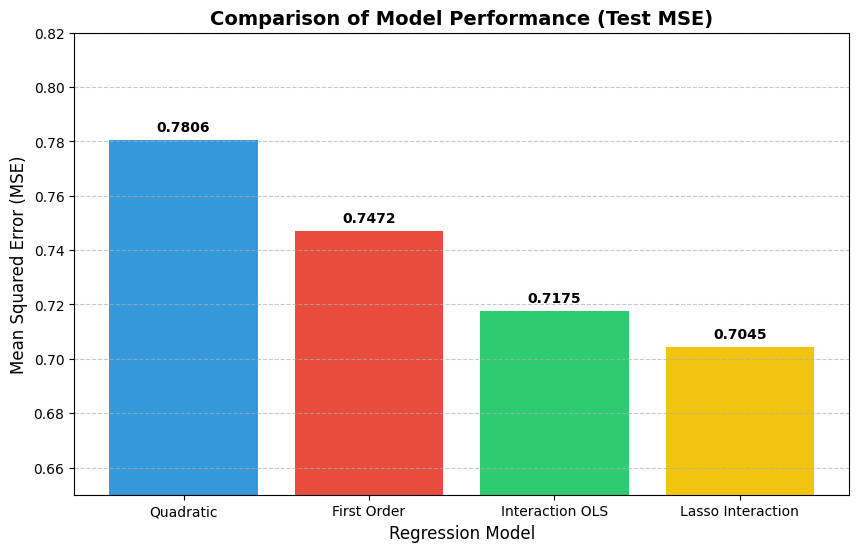

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Model': ['First Order', 'Quadratic', 'Interaction OLS', 'Lasso Interaction'],
    'MSE': [0.7472, 0.7806, 0.7175, 0.7045]
}

df = pd.DataFrame(data)

df_sorted = df.sort_values('MSE', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(df_sorted['Model'], df_sorted['MSE'], color=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'])

plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xlabel('Regression Model', fontsize=12)
plt.title('Comparison of Model Performance (Test MSE)', fontsize=14, fontweight='bold')
plt.ylim(0.65, 0.82) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.4f}', 
             ha='center', va='bottom', fontweight='bold')

plt.savefig('mse_comparison.png', bbox_inches='tight')
plt.show()